In [1]:
import os, glob

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import nugraph as ng

torch.set_float32_matmul_precision("medium")

DATA_PATH = "/home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly"
RUN_NAME = "merged1_Aug24_40k_g4lepdir_tpc_directiononly_axisloss_fixedvpred_nexusfeat_nooptical_ep100_bs64_in8_sp5"
RUN_DIR = f"/home/apaudel/NuGraph/logs/{RUN_NAME}"

ckpts = glob.glob(f"{RUN_DIR}/**/*.ckpt", recursive=True)
assert ckpts, f"No checkpoint found under {RUN_DIR}"
CKPT = max(ckpts, key=os.path.getmtime)

print("DATA_PATH =", DATA_PATH)
print("RUN_NAME  =", RUN_NAME)
print("RUN_DIR   =", RUN_DIR)
print("CKPT      =", CKPT)

raw = torch.load(CKPT, map_location="cpu")
hp = raw.get("hyper_parameters", {})

print("\nCheckpoint hparams:")
for k in [
    "semantic_head", "vertex_head", "direction_head", "event_head",
    "sp_features", "use_optical", "use_pmt_pmt"
]:
    print(f"{k:16s} =", hp.get(k, "MISSING"))

Data = ng.data.H5DataModule
Model = ng.models.NuGraph3

nudata = Data(
    DATA_PATH,
    batch_size=64,
    num_workers=0,
    model=Model,
    shuffle="random",
    featext3d=True,
)

model = Model.load_from_checkpoint(CKPT)
model.eval()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("\nDataset lengths:")
print("train =", len(nudata.train_dataset))
print("val   =", len(nudata.val_dataset))
print("test  =", len(nudata.test_dataset))

print("\nModel sanity:")
print("use_optical =", model.use_optical)
print("sp_net active =", model.encoder.sp_net is not None)
print("has direction_decoder =", hasattr(model, "direction_decoder"))

DATA_PATH = /home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly
RUN_NAME  = merged1_Aug24_40k_g4lepdir_tpc_directiononly_axisloss_fixedvpred_nexusfeat_nooptical_ep100_bs64_in8_sp5
RUN_DIR   = /home/apaudel/NuGraph/logs/merged1_Aug24_40k_g4lepdir_tpc_directiononly_axisloss_fixedvpred_nexusfeat_nooptical_ep100_bs64_in8_sp5
CKPT      = /home/apaudel/NuGraph/logs/merged1_Aug24_40k_g4lepdir_tpc_directiononly_axisloss_fixedvpred_nexusfeat_nooptical_ep100_bs64_in8_sp5/version_0/checkpoints/epoch=99-step=47000.ckpt

Checkpoint hparams:
semantic_head    = False
vertex_head      = False
direction_head   = True
event_head       = False
sp_features      = 5
use_optical      = False
use_pmt_pmt      = False

Dataset lengths:
train = 30080
val   = 1672
test  = 1672

Model sanity:
use_optical = False
sp_net active = True
has direction_decoder = True


,N test,median axis angle deg,mean axis angle deg,p68 axis angle deg,p90 axis angle deg,median |cos axis|,mean |cos axis|,frac axis angle < 10 deg,frac axis angle < 20 deg,frac axis angle < 30 deg,median |Δux|,median |Δuy|,median |Δuz|,mean |Δux|,mean |Δuy|,mean |Δuz|,stored evt.v_pred median err cm,stored evt.v_pred p68 err cm,stored evt.v_pred p90 err cm
0,1672,41.391602,43.756901,56.365501,79.142403,0.7502,0.6619,0.064,0.2028,0.3487,0.2845,0.2681,0.2945,0.3646,0.3607,0.3683,5.4797,8.1207,17.76



Axis angle between true and predicted direction:
  median = 41.39 deg
  mean   = 43.76 deg
  p68    = 56.37 deg
  p90    = 79.14 deg


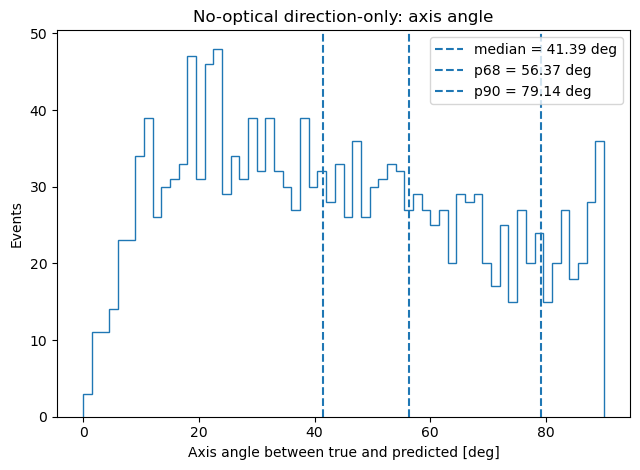

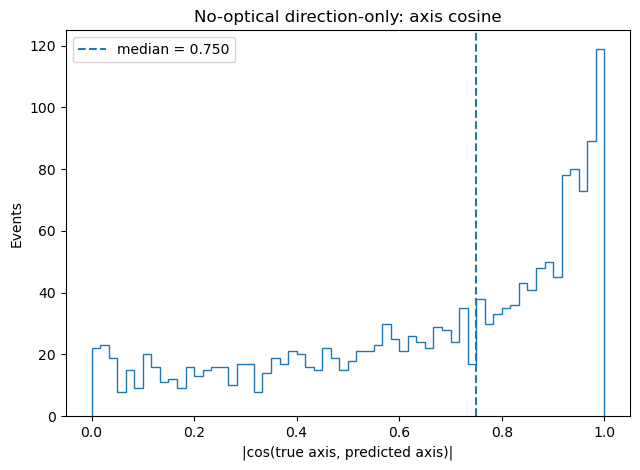

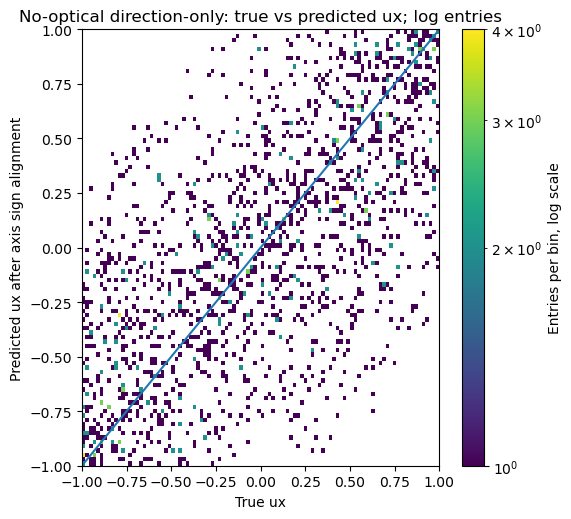

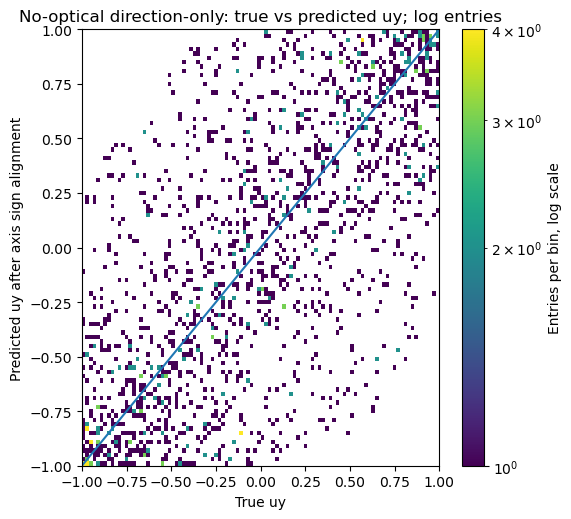

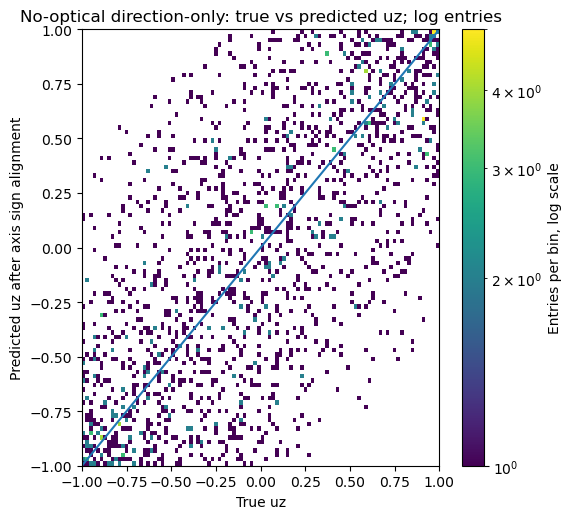

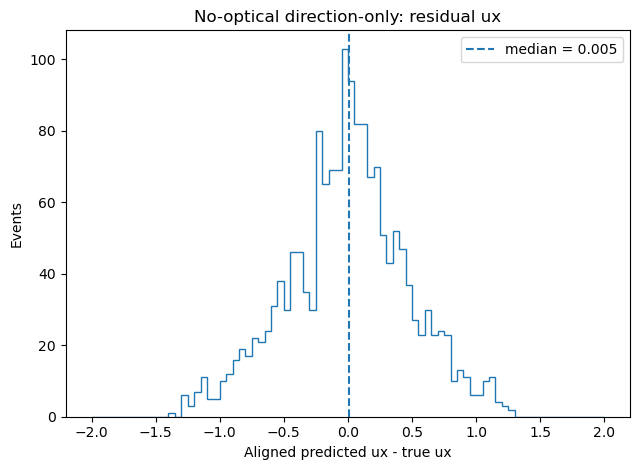

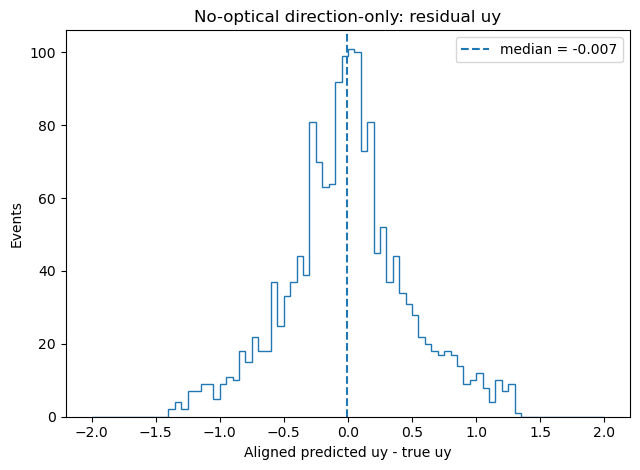

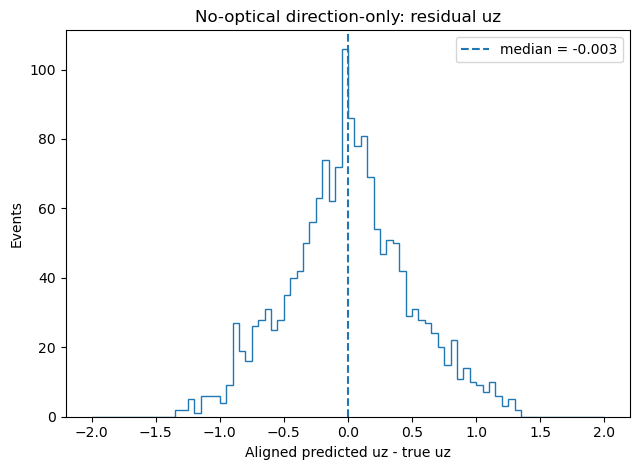

In [2]:
# ============================================================
# Evaluate no-optical direction-only model on test set
# ============================================================

rows = []

with torch.no_grad():
    for batch in nudata.test_dataloader():
        batch = batch.to(device)

        # Fills evt.d
        model(batch, "test")

        evt = batch["evt"]

        rows.append({
            "true_dir": evt.y_dir.detach().float().cpu().numpy(),
            "pred_dir": evt.d.detach().float().cpu().numpy(),
            "stored_vpred": evt.v_pred.detach().float().cpu().numpy(),
            "true_vtx": evt.y_vtx.detach().float().cpu().numpy(),
        })

true_dir = np.concatenate([r["true_dir"] for r in rows], axis=0)
pred_dir = np.concatenate([r["pred_dir"] for r in rows], axis=0)

stored_vpred = np.concatenate([r["stored_vpred"] for r in rows], axis=0)
true_vtx = np.concatenate([r["true_vtx"] for r in rows], axis=0)

def unit(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, 1.0e-12, None)

true_axis = unit(true_dir)
pred_axis = unit(pred_dir)

# Axis-loss comparison:
# u and -u are equivalent.
cos_signed = np.sum(true_axis * pred_axis, axis=1)
cos_signed = np.clip(cos_signed, -1.0, 1.0)

axis_cos = np.abs(cos_signed)
axis_angle_deg = np.degrees(np.arccos(axis_cos))

# Global sign alignment for component comparison.
axis_sign = np.where(cos_signed >= 0.0, 1.0, -1.0)[:, None]
pred_axis_aligned = pred_axis * axis_sign

axis_residual_vec = pred_axis_aligned - true_axis
axis_component_abs = np.abs(axis_residual_vec)

stored_vpred_err = np.linalg.norm(stored_vpred - true_vtx, axis=1)

# ============================================================
# Summary
# ============================================================

summary = {
    "N test": len(axis_angle_deg),

    "median axis angle deg": np.median(axis_angle_deg),
    "mean axis angle deg": np.mean(axis_angle_deg),
    "p68 axis angle deg": np.percentile(axis_angle_deg, 68),
    "p90 axis angle deg": np.percentile(axis_angle_deg, 90),

    "median |cos axis|": np.median(axis_cos),
    "mean |cos axis|": np.mean(axis_cos),

    "frac axis angle < 10 deg": np.mean(axis_angle_deg < 10),
    "frac axis angle < 20 deg": np.mean(axis_angle_deg < 20),
    "frac axis angle < 30 deg": np.mean(axis_angle_deg < 30),

    "median |Δux|": np.median(axis_component_abs[:, 0]),
    "median |Δuy|": np.median(axis_component_abs[:, 1]),
    "median |Δuz|": np.median(axis_component_abs[:, 2]),

    "mean |Δux|": np.mean(axis_component_abs[:, 0]),
    "mean |Δuy|": np.mean(axis_component_abs[:, 1]),
    "mean |Δuz|": np.mean(axis_component_abs[:, 2]),

    "stored evt.v_pred median err cm": np.median(stored_vpred_err),
    "stored evt.v_pred p68 err cm": np.percentile(stored_vpred_err, 68),
    "stored evt.v_pred p90 err cm": np.percentile(stored_vpred_err, 90),
}

display(pd.DataFrame([summary]).round(4))

print("\nAxis angle between true and predicted direction:")
print(f"  median = {np.median(axis_angle_deg):.2f} deg")
print(f"  mean   = {np.mean(axis_angle_deg):.2f} deg")
print(f"  p68    = {np.percentile(axis_angle_deg, 68):.2f} deg")
print(f"  p90    = {np.percentile(axis_angle_deg, 90):.2f} deg")

# ============================================================
# Axis angle and cosine plots
# ============================================================

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_angle_deg, bins=60, range=(0, 90), histtype="step")
plt.axvline(np.median(axis_angle_deg), linestyle="--", label=f"median = {np.median(axis_angle_deg):.2f} deg")
plt.axvline(np.percentile(axis_angle_deg, 68), linestyle="--", label=f"p68 = {np.percentile(axis_angle_deg, 68):.2f} deg")
plt.axvline(np.percentile(axis_angle_deg, 90), linestyle="--", label=f"p90 = {np.percentile(axis_angle_deg, 90):.2f} deg")
plt.xlabel("Axis angle between true and predicted [deg]")
plt.ylabel("Events")
plt.title("No-optical direction-only: axis angle")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_cos, bins=60, range=(0, 1), histtype="step")
plt.axvline(np.median(axis_cos), linestyle="--", label=f"median = {np.median(axis_cos):.3f}")
plt.xlabel("|cos(true axis, predicted axis)|")
plt.ylabel("Events")
plt.title("No-optical direction-only: axis cosine")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# ux, uy, uz true vs predicted
# x/y axes linear, entries shown in log color scale
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    plt.figure(figsize=(5.8, 5.3))

    plt.hist2d(
        true_axis[:, coord],
        pred_axis_aligned[:, coord],
        bins=100,
        range=[[-1, 1], [-1, 1]],
        norm=LogNorm(),
        cmin=1,
    )

    plt.plot([-1, 1], [-1, 1], linewidth=1.5)
    plt.xlabel(f"True u{label}")
    plt.ylabel(f"Predicted u{label} after axis sign alignment")
    plt.title(f"No-optical direction-only: true vs predicted u{label}; log entries")
    cbar = plt.colorbar()
    cbar.set_label("Entries per bin, log scale")
    plt.tight_layout()
    plt.show()

# ============================================================
# Axis residual components
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    residual = axis_residual_vec[:, coord]

    plt.figure(figsize=(6.5, 4.8))
    plt.hist(residual, bins=80, range=(-2, 2), histtype="step")
    plt.axvline(np.median(residual), linestyle="--", label=f"median = {np.median(residual):.3f}")
    plt.xlabel(f"Aligned predicted u{label} - true u{label}")
    plt.ylabel("Events")
    plt.title(f"No-optical direction-only: residual u{label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

RUN_DIR = /home/apaudel/NuGraph/logs/merged1_Aug24_40k_g4lepdir_tpc_directiononly_axisloss_fixedvpred_nexusfeat_nooptical_ep100_bs64_in8_sp5
TB_DIR  = /home/apaudel/NuGraph/logs/merged1_Aug24_40k_g4lepdir_tpc_directiononly_axisloss_fixedvpred_nexusfeat_nooptical_ep100_bs64_in8_sp5/version_0
Event files:
  /home/apaudel/NuGraph/logs/merged1_Aug24_40k_g4lepdir_tpc_directiononly_axisloss_fixedvpred_nexusfeat_nooptical_ep100_bs64_in8_sp5/version_0/events.out.tfevents.1787595932.jupyter-apaudel.9159.0

Number of scalar tags: 40
Number of image tags: 0

Scalar tags:
  direction/angle-deg-median-train
  direction/angle-deg-median-val
  direction/angle-deg-train
  direction/angle-deg-val
  direction/attention-max-weight-train
  direction/attention-max-weight-val
  direction/axis-angle-deg-median-train
  direction/axis-angle-deg-median-val
  direction/axis-angle-deg-train
  direction/axis-angle-deg-val
  direction/axis-cosine-train
  direction/axis-cosine-val
  direction/axis-ux-resolution-trai

,tag,N,first step,last step,first value,last value,min,max
0,direction/angle-deg-median-train,940,49,46999,92.284599,85.662674,35.527039,1.159310e+02
1,direction/angle-deg-median-val,100,469,46999,92.465202,73.910645,72.734467,9.247503e+01
2,direction/angle-deg-train,940,49,46999,93.888962,82.790909,55.915432,1.034242e+02
3,direction/angle-deg-val,100,469,46999,93.129570,80.845901,80.353546,9.312957e+01
4,direction/attention-max-weight-train,940,49,46999,0.123800,0.840538,0.082646,9.357060e-01
5,direction/attention-max-weight-val,100,469,46999,0.101309,0.859412,0.101309,8.697880e-01
6,direction/axis-angle-deg-median-train,940,49,46999,53.223099,40.578953,27.671511,7.036896e+01
7,direction/axis-angle-deg-median-val,100,469,46999,59.120693,41.343922,40.730988,5.912069e+01
8,direction/axis-angle-deg-train,940,49,46999,55.811478,47.631531,34.578358,6.488722e+01
9,direction/axis-angle-deg-val,100,469,46999,57.312515,43.669846,43.365780,5.731251e+01



========== Plot group: loss ==========


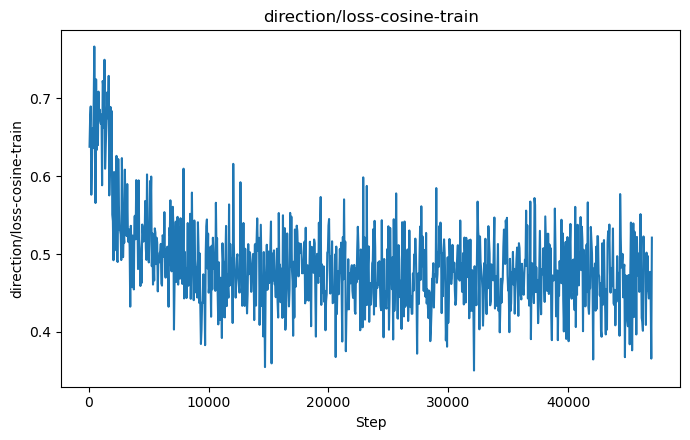

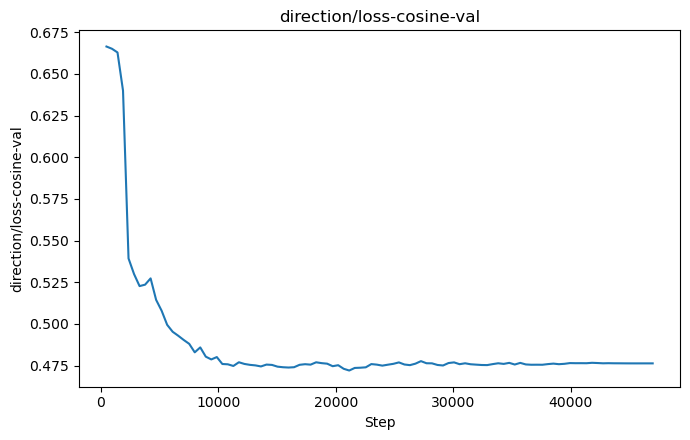

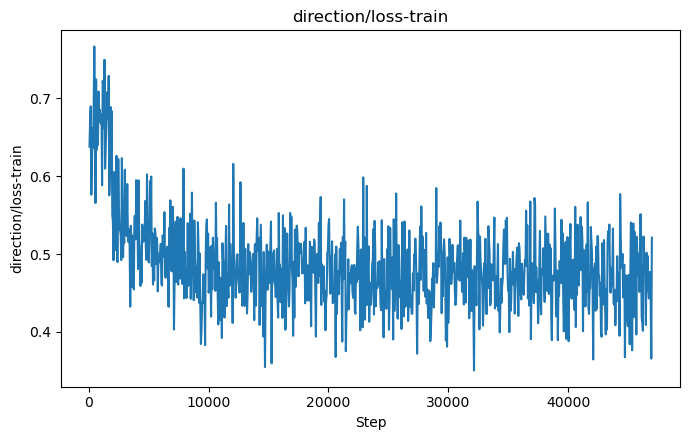

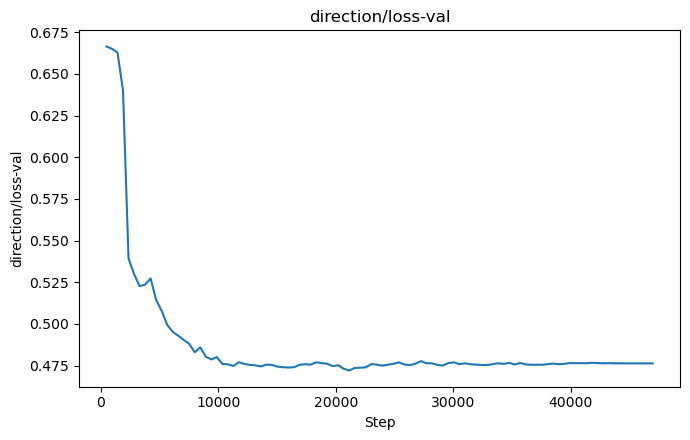

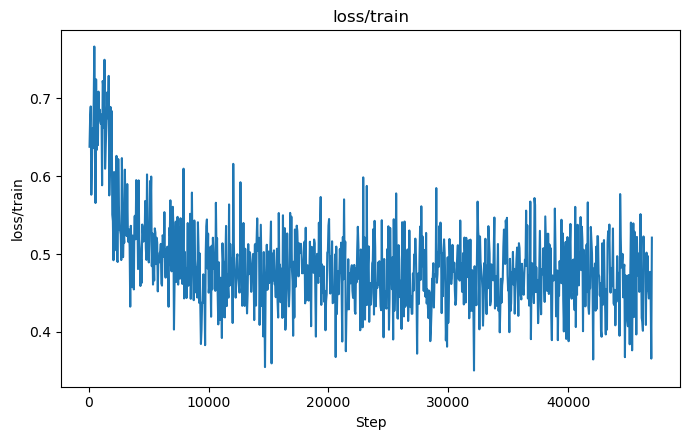

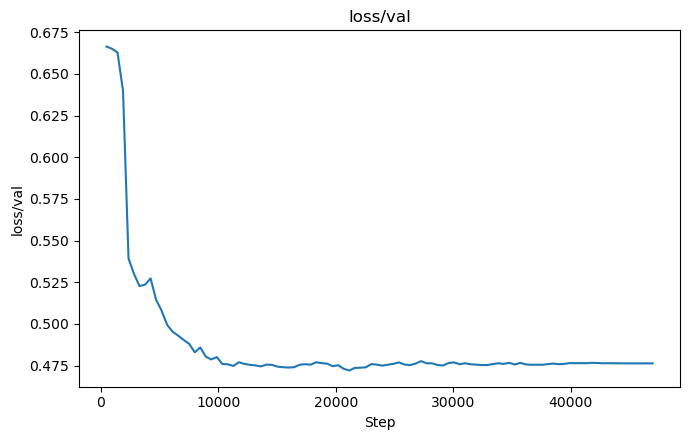


========== Plot group: learning_rate ==========


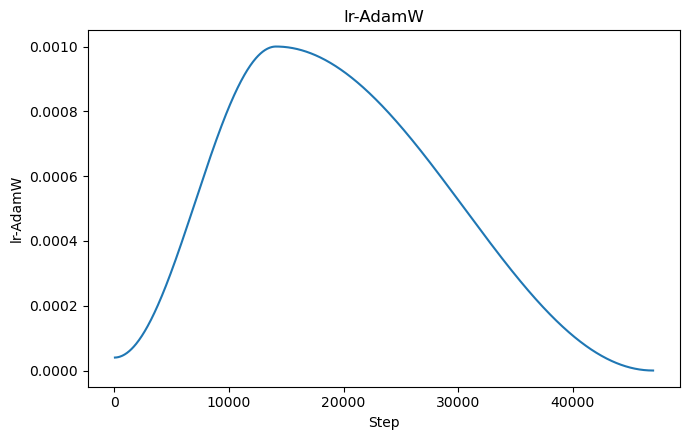


========== Plot group: angle ==========


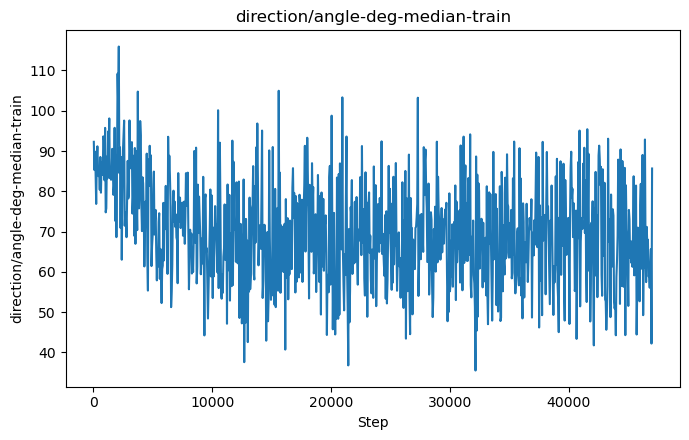

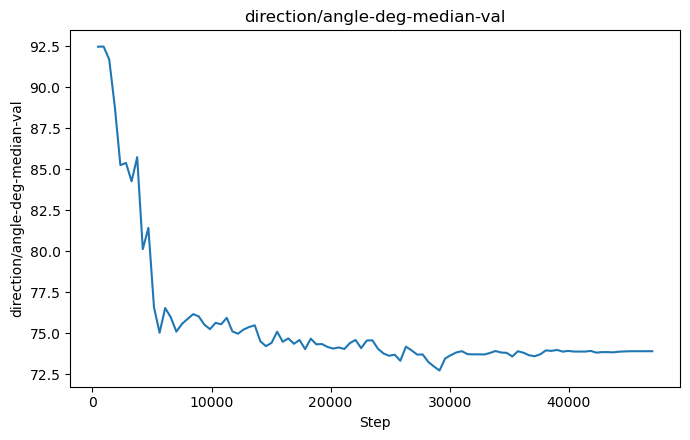

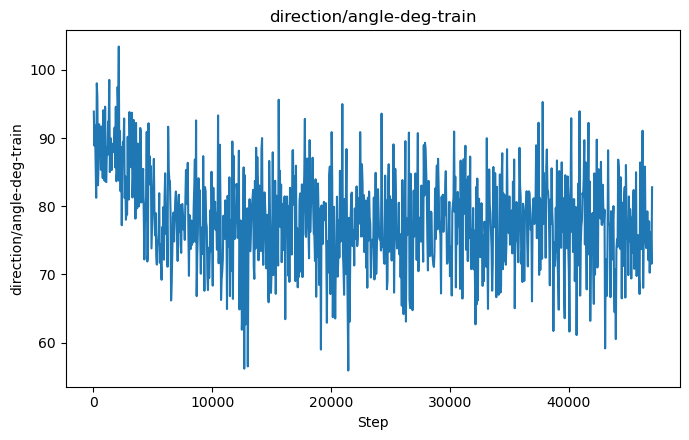

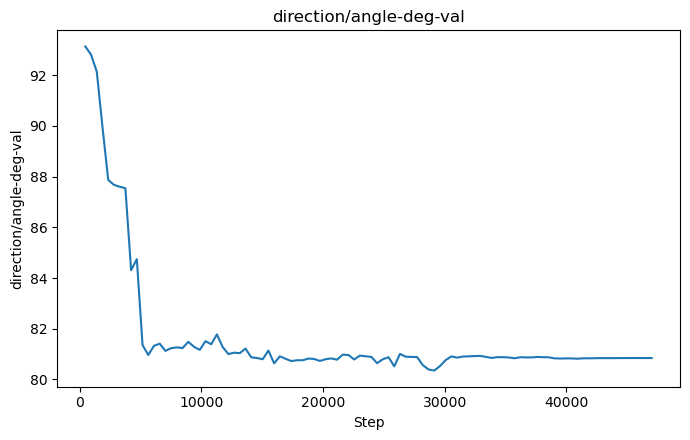

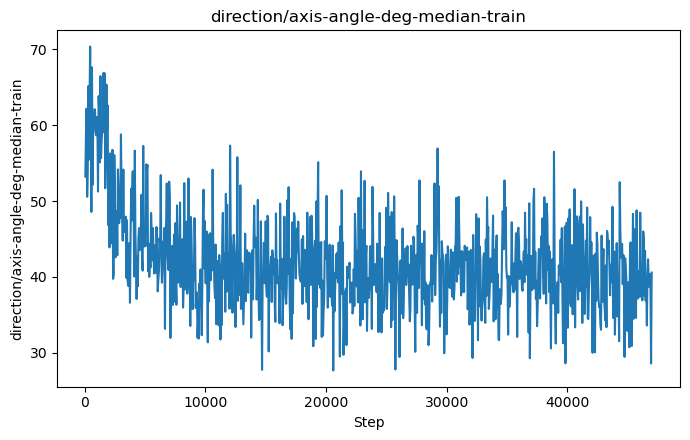

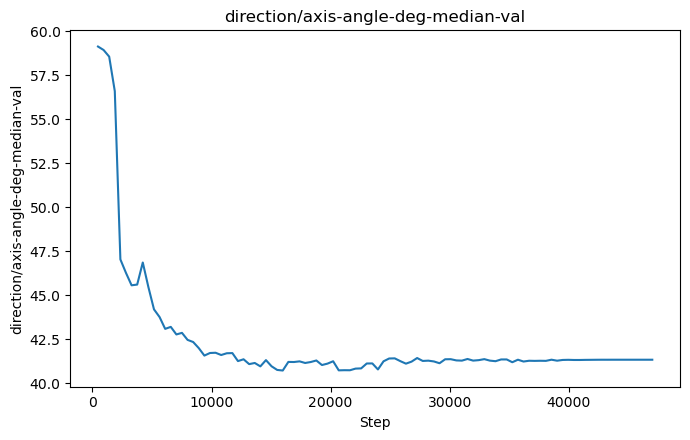

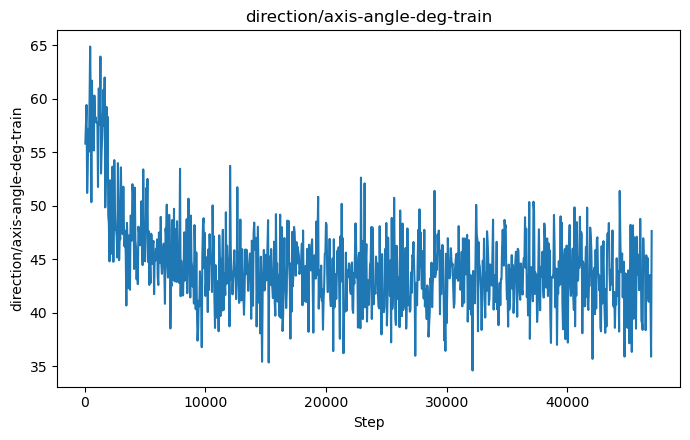

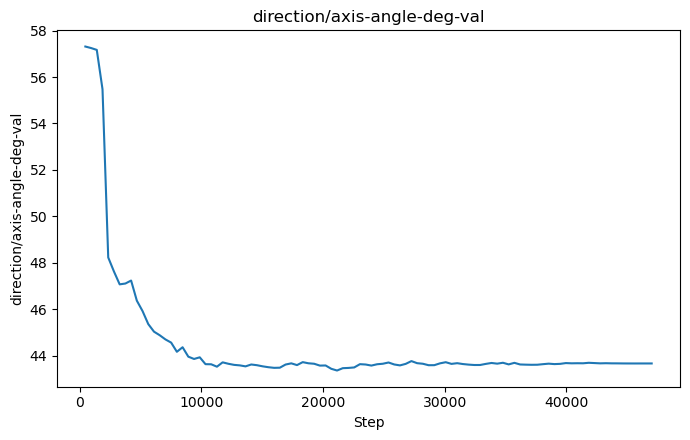


========== Plot group: cosine ==========


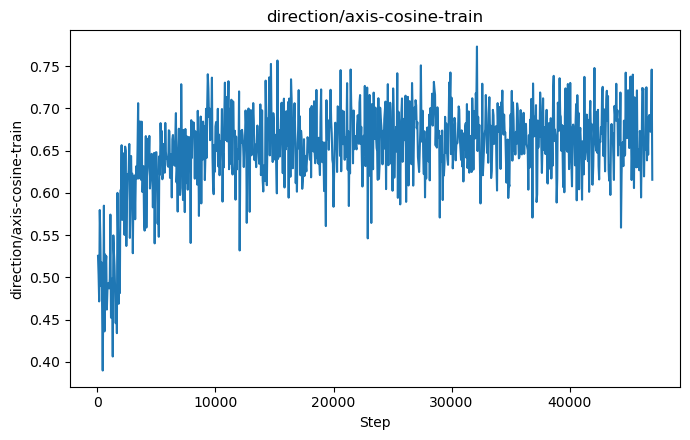

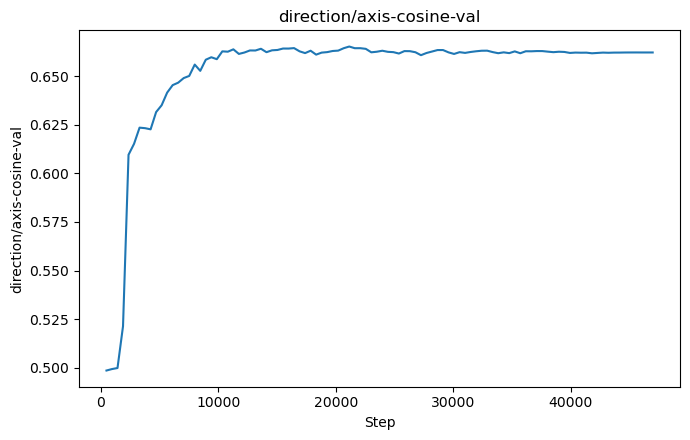

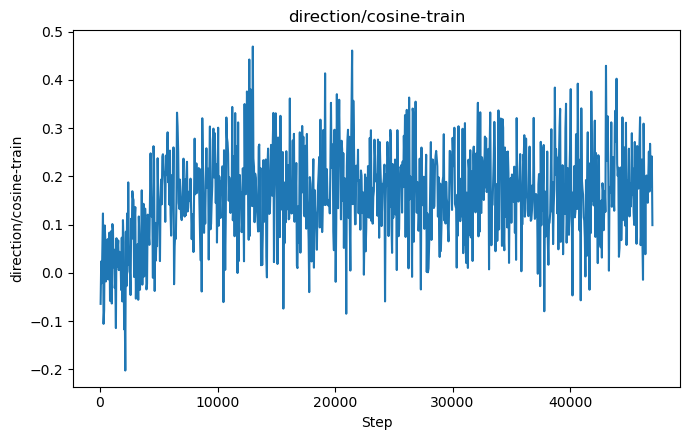

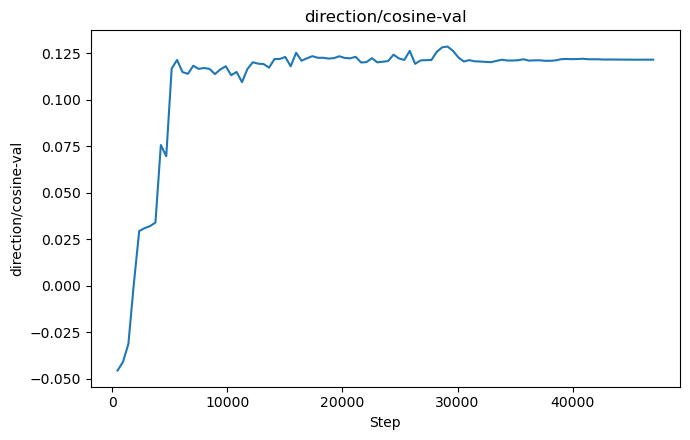

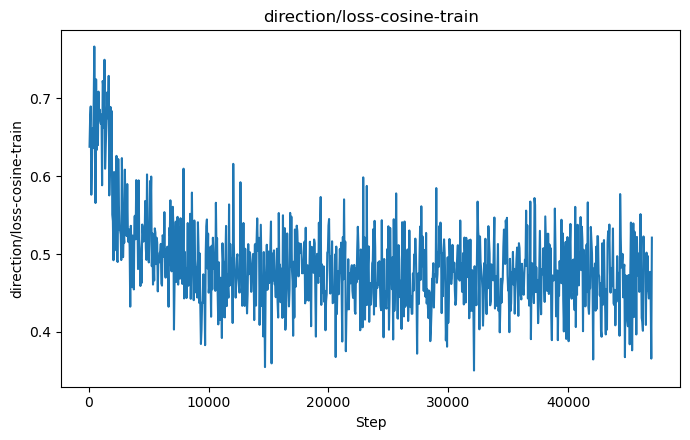

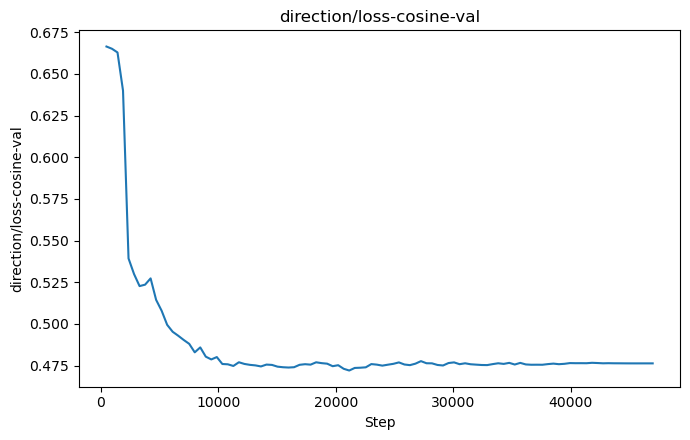


========== Plot group: resolution ==========


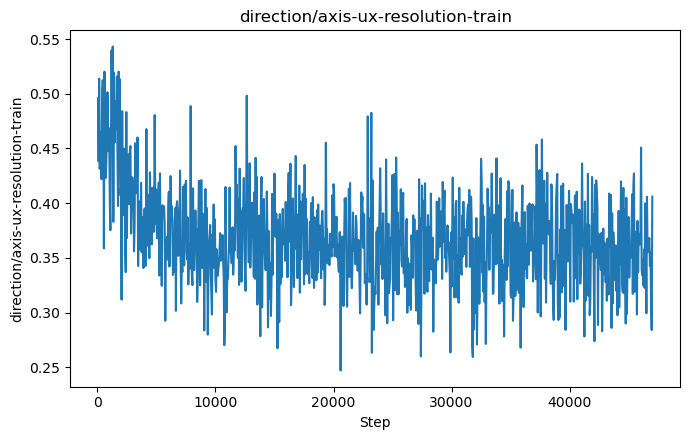

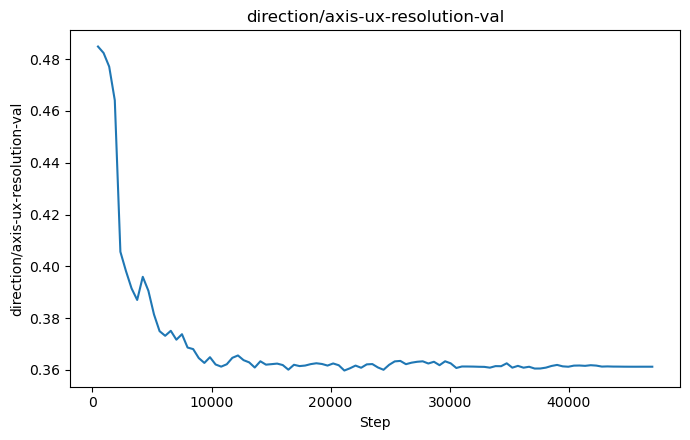

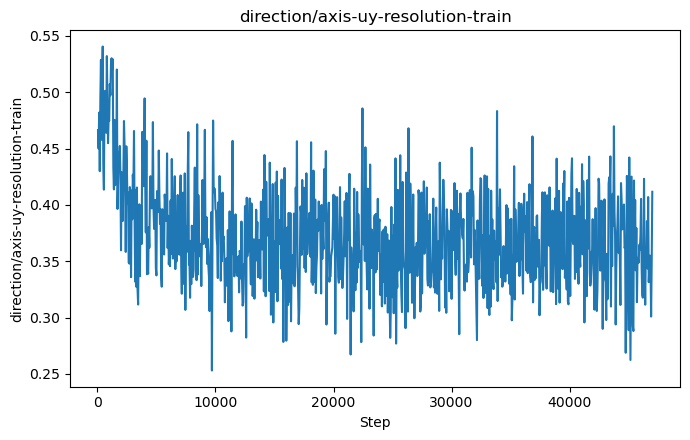

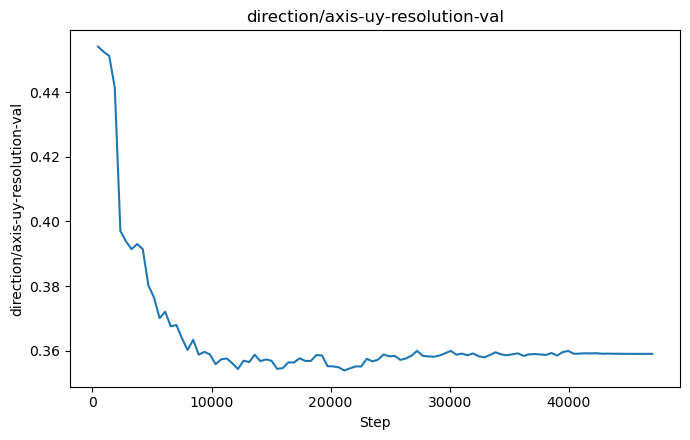

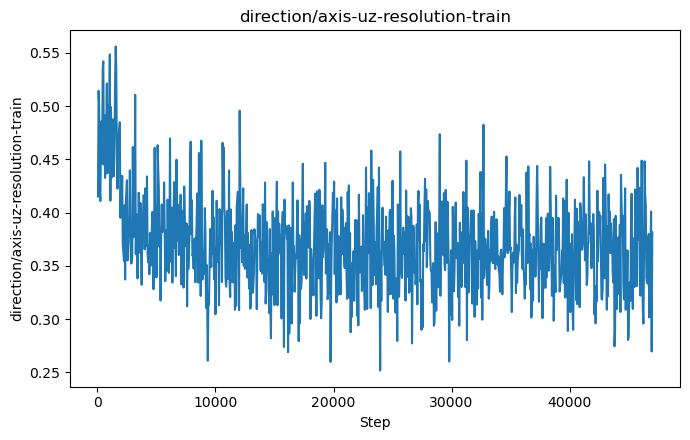

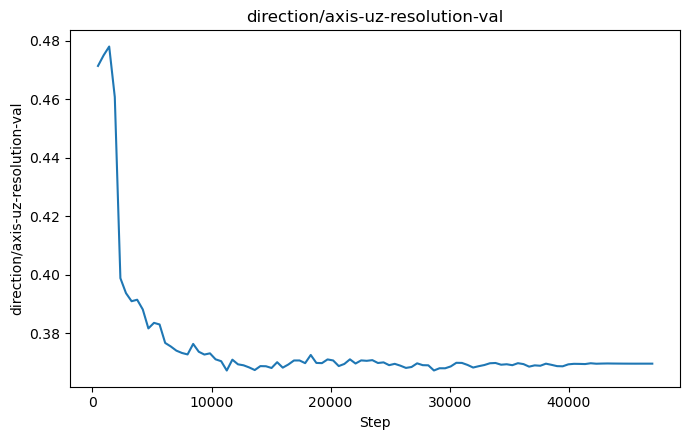

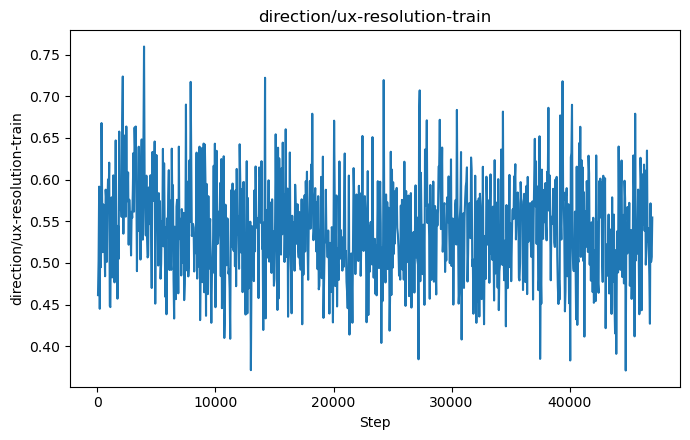

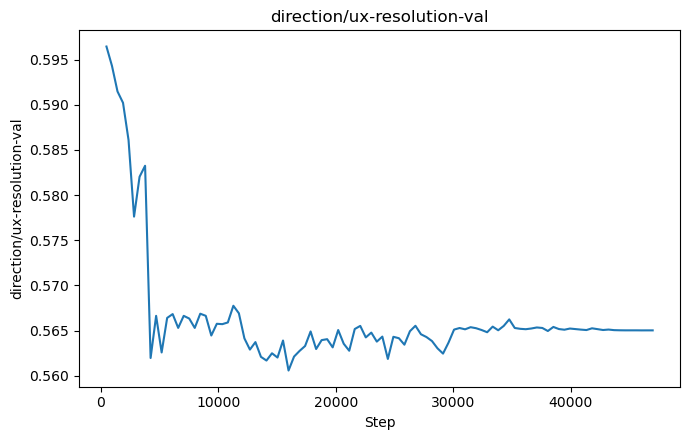

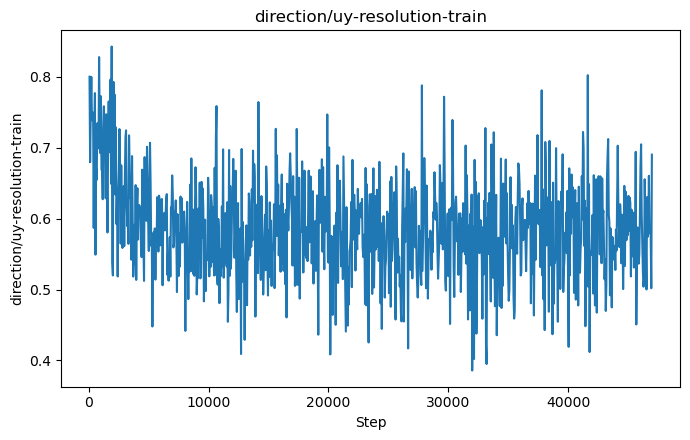

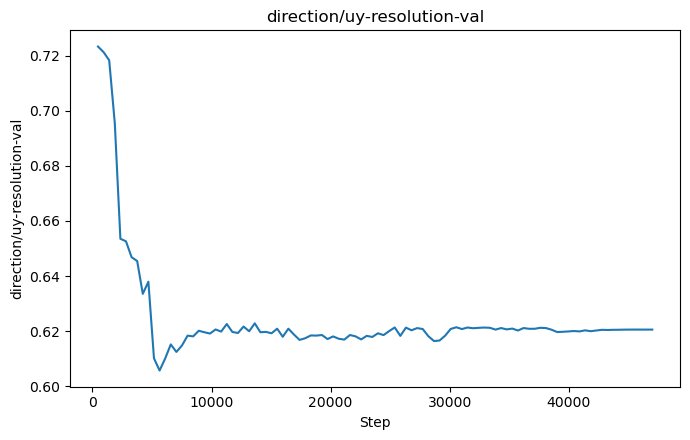

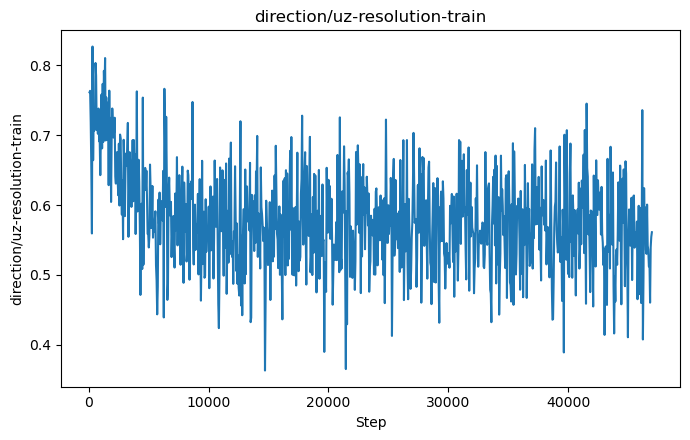

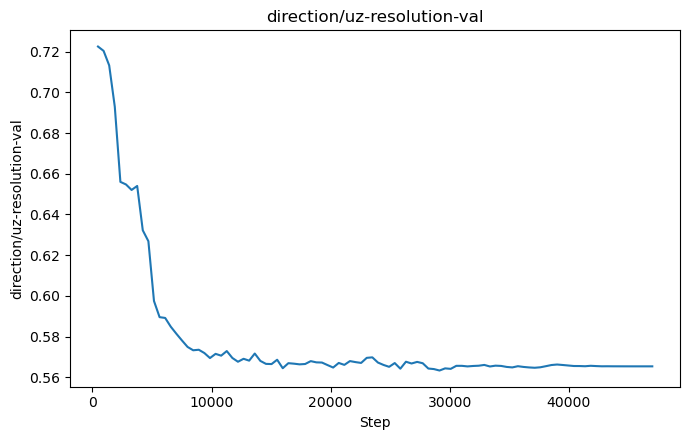


========== Plot group: feature_stats ==========


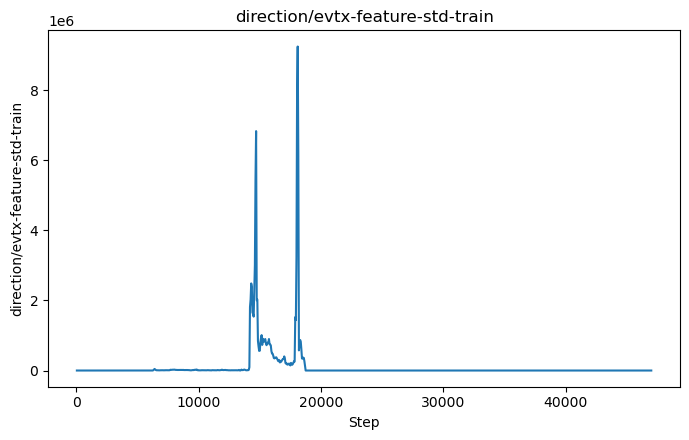

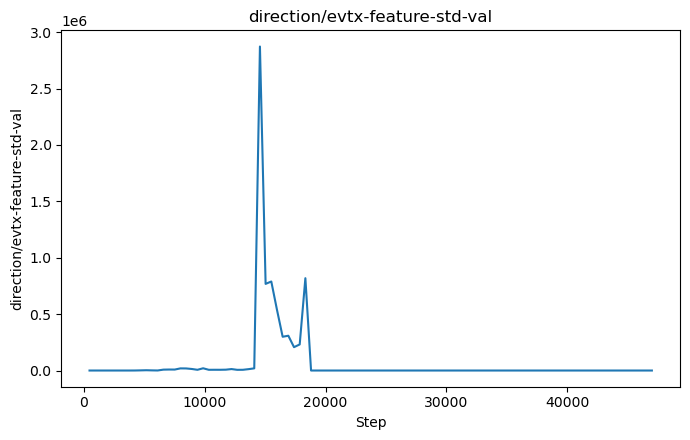

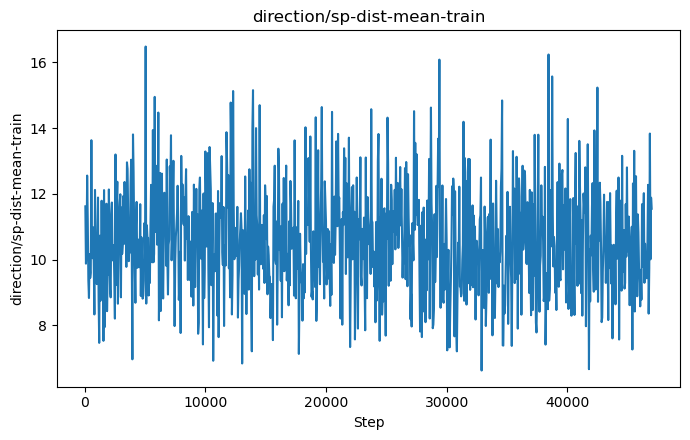

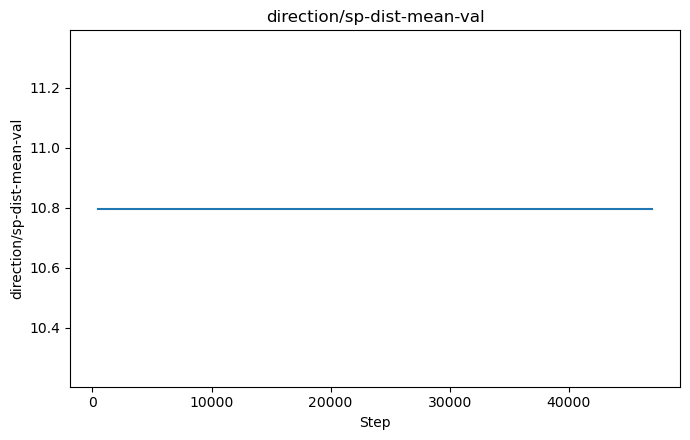


========== Remaining scalar tags ==========


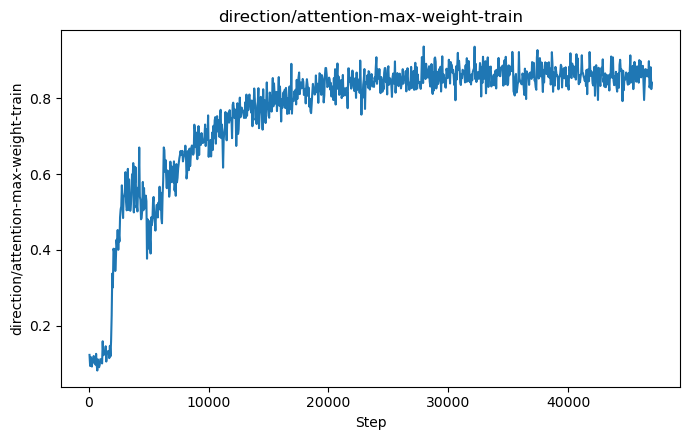

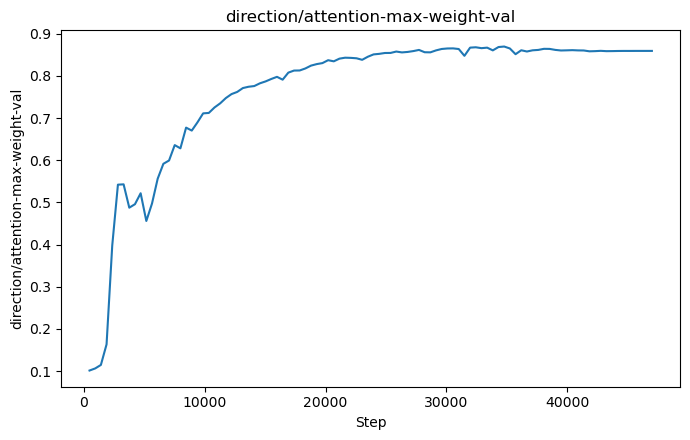

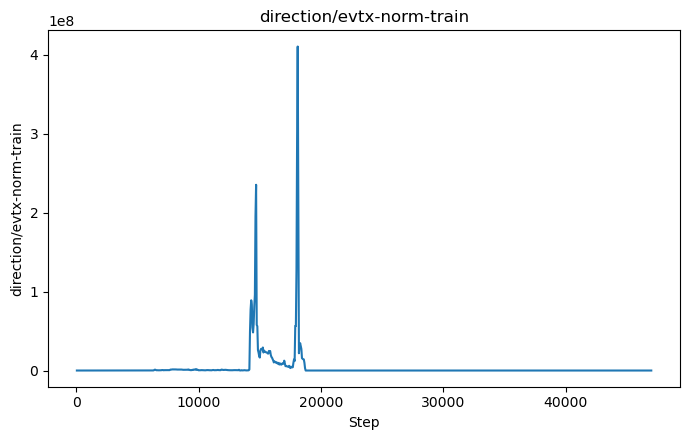

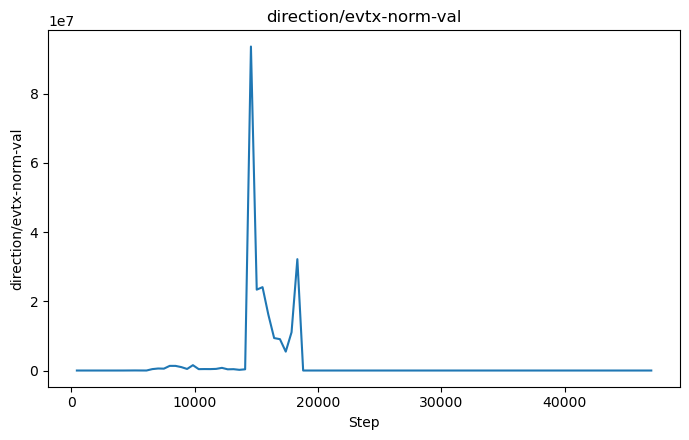

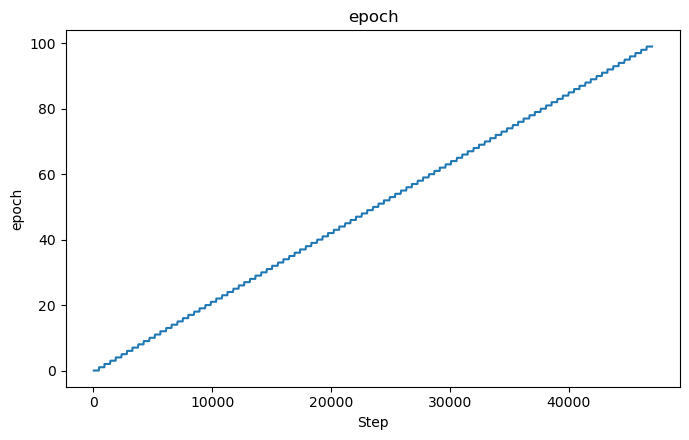

In [3]:
# ============================================================
# Cell 3 — plot all TensorBoard scalar logs for this run
# ============================================================

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

RUN_NAME = "merged1_Aug24_40k_g4lepdir_tpc_directiononly_axisloss_fixedvpred_nexusfeat_nooptical_ep100_bs64_in8_sp5"
RUN_DIR = f"/home/apaudel/NuGraph/logs/{RUN_NAME}"

# Prefer same version as checkpoint from Cell 1 if available.
try:
    TB_DIR = VERSION_DIR
except NameError:
    ckpts = glob.glob(f"{RUN_DIR}/**/*.ckpt", recursive=True)
    assert ckpts, f"No checkpoint found under {RUN_DIR}"
    CKPT = max(ckpts, key=os.path.getmtime)
    TB_DIR = os.path.dirname(os.path.dirname(CKPT))

event_files = sorted(glob.glob(f"{TB_DIR}/events.out.tfevents.*"))
if not event_files:
    event_files = sorted(glob.glob(f"{RUN_DIR}/**/events.out.tfevents.*", recursive=True))
    assert event_files, f"No TensorBoard event files found under {RUN_DIR}"
    TB_DIR = os.path.dirname(event_files[-1])

print("RUN_DIR =", RUN_DIR)
print("TB_DIR  =", TB_DIR)
print("Event files:")
for f in sorted(glob.glob(f"{TB_DIR}/events.out.tfevents.*")):
    print(" ", f)

acc = EventAccumulator(TB_DIR, size_guidance={"scalars": 0, "images": 0})
acc.Reload()

scalar_tags = sorted(acc.Tags().get("scalars", []))
image_tags = sorted(acc.Tags().get("images", []))

print("\nNumber of scalar tags:", len(scalar_tags))
print("Number of image tags:", len(image_tags))

print("\nScalar tags:")
for t in scalar_tags:
    print(" ", t)

# Collect all scalar data.
scalar_data = {}
summary_rows = []

for tag in scalar_tags:
    evs = acc.Scalars(tag)
    steps = np.array([e.step for e in evs])
    vals = np.array([e.value for e in evs], dtype=float)

    scalar_data[tag] = (steps, vals)

    if len(vals):
        summary_rows.append({
            "tag": tag,
            "N": len(vals),
            "first step": int(steps[0]),
            "last step": int(steps[-1]),
            "first value": vals[0],
            "last value": vals[-1],
            "min": np.nanmin(vals),
            "max": np.nanmax(vals),
        })

display(pd.DataFrame(summary_rows).round(6))

# ============================================================
# Plot useful groups first
# ============================================================

groups = {
    "loss": [t for t in scalar_tags if "loss" in t.lower()],
    "learning_rate": [t for t in scalar_tags if "lr" in t.lower() or "learning" in t.lower()],
    "angle": [t for t in scalar_tags if "angle" in t.lower()],
    "cosine": [t for t in scalar_tags if "cos" in t.lower()],
    "resolution": [t for t in scalar_tags if "resolution" in t.lower()],
    "feature_stats": [t for t in scalar_tags if "feature" in t.lower() or "std" in t.lower() or "mean" in t.lower()],
}

plotted = set()

for group_name, tags in groups.items():
    tags = [t for t in tags if t in scalar_data]
    if not tags:
        continue

    print(f"\n========== Plot group: {group_name} ==========")

    for tag in tags:
        steps, vals = scalar_data[tag]
        plotted.add(tag)

        plt.figure(figsize=(7.0, 4.5))
        plt.plot(steps, vals)
        plt.xlabel("Step")
        plt.ylabel(tag)
        plt.title(tag)
        plt.tight_layout()
        plt.show()

# ============================================================
# Plot any remaining scalar tags
# ============================================================

remaining = [t for t in scalar_tags if t not in plotted]

if remaining:
    print("\n========== Remaining scalar tags ==========")

for tag in remaining:
    steps, vals = scalar_data[tag]

    plt.figure(figsize=(7.0, 4.5))
    plt.plot(steps, vals)
    plt.xlabel("Step")
    plt.ylabel(tag)
    plt.title(tag)
    plt.tight_layout()
    plt.show()

,N,vpred err median cm,vpred err mean cm,vpred err p68 cm,vpred err p90 cm,axis angle median deg,axis angle mean deg,axis angle p68 deg,axis angle p90 deg,"Pearson corr(vertex err, angle)","Spearman corr(vertex err, angle)"
0,1672,5.4797,8.3818,8.1207,17.76,41.391602,43.756901,56.365501,79.142403,-0.0997,-0.1466


Correlation test:
  Pearson  r(|v_pred - y_vtx|, axis angle)  = -0.0997
  Spearman r(|v_pred - y_vtx|, axis angle)  = -0.1466

Median values:
  median |v_pred - y_vtx| = 5.48 cm
  median axis angle       = 41.39 deg


,vertex err quartile,vpred err range cm,N,median vpred err cm,median axis angle deg,mean axis angle deg,p68 axis angle deg,p90 axis angle deg,frac axis angle < 20 deg,frac axis angle < 30 deg
0,Q1,0.52–3.29,418,2.2789,46.278599,47.785301,61.193401,81.424103,0.1435,0.2560
1,Q2,3.29–5.48,418,4.3247,46.812302,46.709301,57.926800,79.111900,0.1483,0.2632
2,Q3,5.48–9.66,418,7.1975,37.529999,41.644001,54.655300,78.517700,0.2249,0.4019
3,Q4,9.66–117.61,418,15.2844,32.015099,38.889099,51.629200,78.257599,0.2943,0.4737


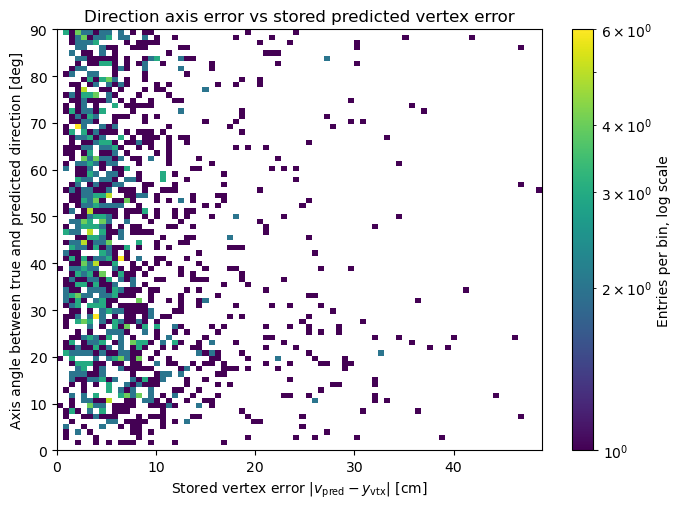

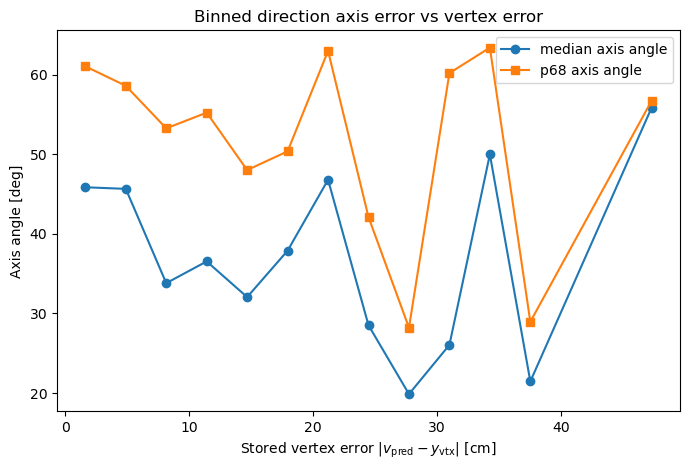

,bin center vertex err cm,N,median axis angle deg,p68 axis angle deg
0,1.631000,409,45.861000,61.058998
1,4.892000,571,45.660999,58.612999
2,8.153000,284,33.810001,53.268002
3,11.414000,144,36.542999,55.241001
4,14.675000,73,32.058998,48.021999
5,17.936001,51,37.894001,50.382000
6,21.197001,28,46.804001,63.000000
7,24.458000,32,28.514999,42.108002
8,27.719000,21,19.867001,28.211000
9,30.980000,18,26.049000,60.210999


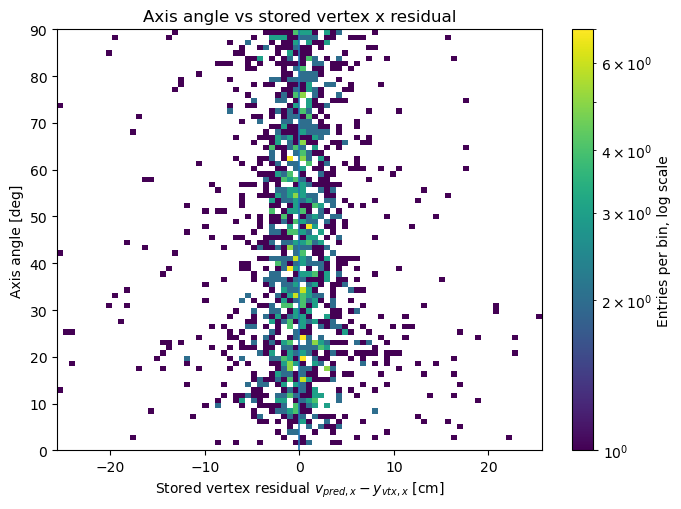

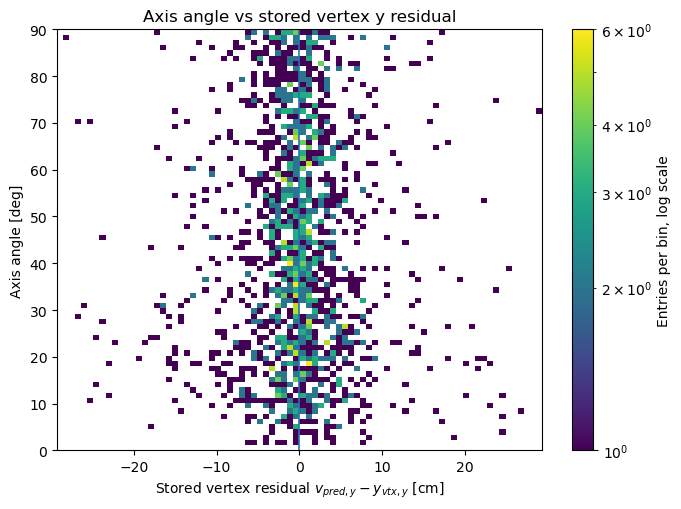

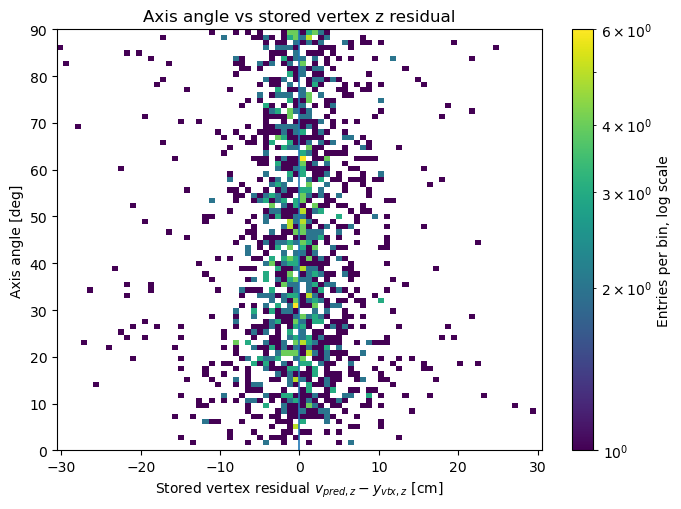

In [4]:
# ============================================================
# Test: does direction error correlate with stored predicted vertex error?
# For predicted-vertex run:
#   x-axis = |evt.v_pred - evt.y_vtx| [cm]
#   y-axis = axis angle between evt.d and evt.y_dir [deg]
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Direction axis angle
def unit(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, 1.0e-12, None)

true_axis = unit(true_dir)
pred_axis = unit(pred_dir)

cos_signed = np.sum(true_axis * pred_axis, axis=1)
cos_signed = np.clip(cos_signed, -1.0, 1.0)

axis_cos = np.abs(cos_signed)
axis_angle_deg = np.degrees(np.arccos(axis_cos))

# Stored predicted vertex residual wrt truth
vpred_residual = stored_vpred - true_vtx
vpred_err_3d = np.linalg.norm(vpred_residual, axis=1)

# Component residuals
vpred_dx = vpred_residual[:, 0]
vpred_dy = vpred_residual[:, 1]
vpred_dz = vpred_residual[:, 2]

# ============================================================
# Correlation numbers
# ============================================================

try:
    from scipy.stats import spearmanr, pearsonr

    pearson_r, pearson_p = pearsonr(vpred_err_3d, axis_angle_deg)
    spearman_r, spearman_p = spearmanr(vpred_err_3d, axis_angle_deg)
except Exception:
    pearson_r = np.corrcoef(vpred_err_3d, axis_angle_deg)[0, 1]
    pearson_p = np.nan

    rank_x = pd.Series(vpred_err_3d).rank().values
    rank_y = pd.Series(axis_angle_deg).rank().values
    spearman_r = np.corrcoef(rank_x, rank_y)[0, 1]
    spearman_p = np.nan

summary = {
    "N": len(axis_angle_deg),

    "vpred err median cm": np.median(vpred_err_3d),
    "vpred err mean cm": np.mean(vpred_err_3d),
    "vpred err p68 cm": np.percentile(vpred_err_3d, 68),
    "vpred err p90 cm": np.percentile(vpred_err_3d, 90),

    "axis angle median deg": np.median(axis_angle_deg),
    "axis angle mean deg": np.mean(axis_angle_deg),
    "axis angle p68 deg": np.percentile(axis_angle_deg, 68),
    "axis angle p90 deg": np.percentile(axis_angle_deg, 90),

    "Pearson corr(vertex err, angle)": pearson_r,
    "Spearman corr(vertex err, angle)": spearman_r,
}

display(pd.DataFrame([summary]).round(4))

print("Correlation test:")
print(f"  Pearson  r(|v_pred - y_vtx|, axis angle)  = {pearson_r:.4f}")
print(f"  Spearman r(|v_pred - y_vtx|, axis angle)  = {spearman_r:.4f}")
print()
print("Median values:")
print(f"  median |v_pred - y_vtx| = {np.median(vpred_err_3d):.2f} cm")
print(f"  median axis angle       = {np.median(axis_angle_deg):.2f} deg")

# ============================================================
# Quartile table: does best vertex quartile still have bad direction?
# ============================================================

quartile_edges = np.percentile(vpred_err_3d, [0, 25, 50, 75, 100])

quartile_rows = []
for i in range(4):
    lo = quartile_edges[i]
    hi = quartile_edges[i + 1]

    if i < 3:
        m = (vpred_err_3d >= lo) & (vpred_err_3d < hi)
    else:
        m = (vpred_err_3d >= lo) & (vpred_err_3d <= hi)

    quartile_rows.append({
        "vertex err quartile": f"Q{i+1}",
        "vpred err range cm": f"{lo:.2f}–{hi:.2f}",
        "N": int(m.sum()),
        "median vpred err cm": np.median(vpred_err_3d[m]),
        "median axis angle deg": np.median(axis_angle_deg[m]),
        "mean axis angle deg": np.mean(axis_angle_deg[m]),
        "p68 axis angle deg": np.percentile(axis_angle_deg[m], 68),
        "p90 axis angle deg": np.percentile(axis_angle_deg[m], 90),
        "frac axis angle < 20 deg": np.mean(axis_angle_deg[m] < 20),
        "frac axis angle < 30 deg": np.mean(axis_angle_deg[m] < 30),
    })

quartile_df = pd.DataFrame(quartile_rows)
display(quartile_df.round(4))

# ============================================================
# Main plot: axis angle vs vertex error
# Entries shown in log scale
# ============================================================

plt.figure(figsize=(7.0, 5.2))

plt.hist2d(
    vpred_err_3d,
    axis_angle_deg,
    bins=[80, 80],
    range=[[0, np.percentile(vpred_err_3d, 99)], [0, 90]],
    norm=LogNorm(),
    cmin=1,
)

plt.xlabel(r"Stored vertex error $|v_{\rm pred} - y_{\rm vtx}|$ [cm]")
plt.ylabel("Axis angle between true and predicted direction [deg]")
plt.title("Direction axis error vs stored predicted vertex error")
cbar = plt.colorbar()
cbar.set_label("Entries per bin, log scale")
plt.tight_layout()
plt.show()

# ============================================================
# Binned median angle vs vertex error
# ============================================================

xmax = np.percentile(vpred_err_3d, 99)
bins = np.linspace(0, xmax, 16)

bin_centers = []
bin_medians = []
bin_p68 = []
bin_counts = []

for lo, hi in zip(bins[:-1], bins[1:]):
    m = (vpred_err_3d >= lo) & (vpred_err_3d < hi)
    if m.sum() < 5:
        continue

    bin_centers.append(0.5 * (lo + hi))
    bin_medians.append(np.median(axis_angle_deg[m]))
    bin_p68.append(np.percentile(axis_angle_deg[m], 68))
    bin_counts.append(m.sum())

bin_centers = np.array(bin_centers)
bin_medians = np.array(bin_medians)
bin_p68 = np.array(bin_p68)
bin_counts = np.array(bin_counts)

plt.figure(figsize=(7.0, 4.8))
plt.plot(bin_centers, bin_medians, marker="o", label="median axis angle")
plt.plot(bin_centers, bin_p68, marker="s", label="p68 axis angle")
plt.xlabel(r"Stored vertex error $|v_{\rm pred} - y_{\rm vtx}|$ [cm]")
plt.ylabel("Axis angle [deg]")
plt.title("Binned direction axis error vs vertex error")
plt.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "bin center vertex err cm": bin_centers,
    "N": bin_counts,
    "median axis angle deg": bin_medians,
    "p68 axis angle deg": bin_p68,
}).round(3))

# ============================================================
# Optional: angle vs vertex residual components
# This checks whether x/y/z vertex mistakes matter differently.
# ============================================================

for residual, label in [(vpred_dx, "x"), (vpred_dy, "y"), (vpred_dz, "z")]:
    plt.figure(figsize=(7.0, 5.2))

    lim = np.percentile(np.abs(residual), 99)

    plt.hist2d(
        residual,
        axis_angle_deg,
        bins=[80, 80],
        range=[[-lim, lim], [0, 90]],
        norm=LogNorm(),
        cmin=1,
    )

    plt.axvline(0, linewidth=1.2)
    plt.xlabel(rf"Stored vertex residual $v_{{pred,{label}}} - y_{{vtx,{label}}}$ [cm]")
    plt.ylabel("Axis angle [deg]")
    plt.title(f"Axis angle vs stored vertex {label} residual")
    cbar = plt.colorbar()
    cbar.set_label("Entries per bin, log scale")
    plt.tight_layout()
    plt.show()